#### Welcome to Assignment  1 of Machine Learning Course 5DV238! 
The focus of this assignment is supervised machine learning. The task is to implement a classifier for cancer diagnosis (whether the diagnosis is malignant or benign), and a regression model to predict housing prices. You will also get familiar with Jupyter notebooks and machine learning libraries, such as Sklearn (https://scikit-learn.org/stable/) and Pandas by applying three different classification (Logistic Regression, SVM, Decision Tree) and regression (Linear Regression, Decision Tree) algorithms. 

#### Datasets
1) Breast Cancer Wisconsin (Diagnostic) Database.
https://archive.ics.uci.edu/ml/datasets/breast+cancer+wisconsin+(diagnostic)

2) The California Housing Dataset https://developers.google.com/machine-learning/crash-course/california-housing-data-description

Both datasets come with descriptions explaining their features.

#### Libraries 
This assignment uses the following libraries: pandas, numpy, matplotlib, seaborn, tensorlfow, scikit-learn

install with e.g. ```conda install pandas``` or ```pip install pandas```


#### Deadline
March 02nd, 2026 (23:59)
Resubmission deadlines - check canvas page

#### Grading
The assignment consists of 10 tasks (a mix of coding and questions about the results) and 3 more general questions. To pass, you have to answer all three general questions and get at least 13 points for completing the tasks (maximum is 20)

#### Submission
Submission can be done individually or in pairs. 
Rename this notebook file as "FirstName1_LastName1_FirstName2_LastName2_assignment_1.ipynb" and upload to Canvas/Assignments/Assignment-1.
Do not forget to make sure that all the cell outputs are saved.

# Part 1: Classification

### Preparing the data breast cancer dataset

In [1]:
from sklearn.datasets import load_breast_cancer

In [2]:
cancer = load_breast_cancer()
#print the predicton labels (target names)
list(cancer.target_names)

[np.str_('malignant'), np.str_('benign')]

In [3]:
# Organizing the dataset
label_names = cancer['target_names']
labels = cancer['target']
feature_names = cancer['feature_names']
features = cancer['data']

 ### Task 1: Exploring the data (1p)

#### How many features and how many instances are in the dataset?

In [4]:
# Count and print the output here
print(f"Number of instances: {features.shape[0]}")
print(f"Number of features: {features.shape[1]}")

Number of instances: 569
Number of features: 30


#### How many instances are there with the benign and with the malignant diagnosis?

In [5]:
# Count and print the output here
import numpy as np
unique, counts = np.unique(labels, return_counts=True)
for class_index, count in zip(unique, counts):
    print(f"{label_names[class_index]}: {count}")

malignant: 212
benign: 357


 #### Splitting the data into train (70%) and test (30%) parts with train_test_split. Note that for this introductory assignment we are not creating a separate evaluation dataset and use the test data for parameter tuning.

In [6]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    cancer.data,
    cancer.target,
    test_size=0.3,
    stratify=cancer.target,
    random_state=42
 )

### Question 1: What if the dataset is unbalanced and one class is underrepresented in the train (or test) set? How can we mitigate that? The split is random, so every time you rerun the cell, the results may be slightly different. How can you make them reproducible? (0p, mendatory)

If one class is underrepresented, the model can become biased toward the majority class, so accuracy alone may look better than the model actually is. A good way to reduce this problem is to use stratified splitting (`stratify=y`) so train and test keep similar class proportions. You can also use class weights or resampling if needed. To make results reproducible, set a fixed seed such as `random_state=42`.

### General Machine Learning pipeline
* Prepare the dataset and set aside the test data (and, typically, we also split the rest into training and evaluation data)
* Implementing a machine learning algorithm
* Train the algorithm on the train data, evaluate it on evaluation data (or via crossvalidation), change the parameters, repeat the step until the results are good enough.
* Perform the final evaluation using the test data that has not been used so far.

Note that in this assigment, you are not requied to implment classifiction algorithms, they are already implemented in sklearn. You task is to choose the correct implementation with suitable parameters. 

## Logistic Regression

###  Task 2: Creating and running a logistic regression model (1p) 

In [7]:
from sklearn.linear_model import LogisticRegression
logreg = LogisticRegression(max_iter=10000, random_state=42)
logreg.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

#### Calculate and output the accuracy of the model on the train data

In [8]:
train_accuracy = logreg.score(X_train, y_train)
print(f"Logistic Regression train accuracy: {train_accuracy:.3f}")

Logistic Regression train accuracy: 0.970


#### Make predictions for the test data and calculate the accuracy

In [9]:
from sklearn.metrics import accuracy_score
y_pred = logreg.predict(X_test)
test_accuracy = accuracy_score(y_test, y_pred)
print(f"Logistic Regression test accuracy: {test_accuracy:.3f}")

Logistic Regression test accuracy: 0.947


### Task 3: Changing parameters and optimisation (2p)

#### Train a different logistic regression model by setting the regularization parameter C to 100.

In [10]:
logreg_c100 = LogisticRegression(C=100, max_iter=10000, random_state=42)
logreg_c100.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",100
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

#### Calculate train and test accuracy for the new model

In [11]:
print(f"C=100 train accuracy: {logreg_c100.score(X_train, y_train):.3f}")
print(f"C=100 test accuracy: {logreg_c100.score(X_test, y_test):.3f}")

C=100 train accuracy: 0.990
C=100 test accuracy: 0.947


 #### Create another model with the regularization parameter C at 0.01, and calculate train and test accuracy 

In [12]:
logreg_c001 = LogisticRegression(C=0.01, max_iter=10000, random_state=42)
logreg_c001.fit(X_train, y_train)
print(f"C=0.01 train accuracy: {logreg_c001.score(X_train, y_train):.3f}")
print(f"C=0.01 test accuracy: {logreg_c001.score(X_test, y_test):.3f}")

C=0.01 train accuracy: 0.950
C=0.01 test accuracy: 0.947


#### Describe the results, did the models perform differently? Why? Which C value worked best?

The models performed slightly differently because `C` controls the regularization strength. With a larger `C` (100), regularization is weaker, so the model fits training data more closely and can overfit more easily. With a small `C` (0.01), regularization is stronger, which can lead to underfitting. In my run, test accuracy was very similar across these values, while `C=100` gave the highest training accuracy.

## SVM

 #### To use SVM, the data has to be scaled, in this case, we apply MinMaxScaler to the entire\* dataset
 \*Note that in a real life scenario, the test data should normally be set aside before any processing.

In [13]:
from sklearn.preprocessing import MinMaxScaler
X, y = load_breast_cancer(return_X_y=True)
X_scaled = MinMaxScaler().fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, stratify=y, random_state=42
)

### Task 4: Create and run an SVM model (1p)

#### Train an SVM model using sklearn

In [14]:
import numpy as np
from sklearn.svm import SVC
svm_model = SVC()
svm_model.fit(X_train, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


#### Calculate and output the accuracy of the model on the train data

In [15]:
print('SVM train accuracy: {:.3f}'.format(svm_model.score(X_train, y_train)))

SVM train accuracy: 0.980


#### Make predictions for the test data and calculate the accuracy

In [16]:
svm_pred = svm_model.predict(X_test)
print('SVM test accuracy: {:.3f}'.format(np.mean(svm_pred == y_test)))

SVM test accuracy: 0.977


### Question 2: What kernel is the default for an sklearn SVC model? Which other common kernels are you familiar with and what is the difference? (0p, mendatory)

The default kernel in `sklearn.svm.SVC` is the RBF kernel (`kernel='rbf'`). Other common kernels are `linear`, `poly`, and `sigmoid`. A linear kernel gives a linear decision boundary, while RBF and polynomial kernels can model more complex non-linear patterns. In practice, RBF is often a good default when the classes are not linearly separable.

### Task 5: Implement your own gaussian kernel function (3p)

In [19]:
def my_kernel_gaussian(X, Y, gamma=1.0):
    # write a gaussian kernel function
    X_norm = np.sum(X ** 2, axis=1)[:, np.newaxis]
    Y_norm = np.sum(Y ** 2, axis=1)[np.newaxis, :]
    squared_dist = X_norm + Y_norm - 2 * np.dot(X, Y.T)
    return np.exp(-gamma * squared_dist)

#### Run the cells below to replace the default kenel with my_kernel_gaussian and see the results

In [20]:
svm_gaussian_kernel = SVC(kernel=my_kernel_gaussian)
svm_gaussian_kernel.fit(X_train, y_train)
svm_gaussian_kernel = SVC(kernel=my_kernel_gaussian)
svm_gaussian_kernel.fit(X_train, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",<function my_...001D45CA06520>
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [21]:
#### print out the accuracy of SVM models with kernel function my_kernel_gaussian
print('The accuracy on the training set: {:.3f}'.format(svm_gaussian_kernel.score(X_train, y_train)))
print('The accuracy on the test set: {:.3f}'.format(svm_gaussian_kernel.score(X_test, y_test)))

The accuracy on the training set: 0.980
The accuracy on the test set: 0.977


## Decision Tree

In [22]:
cancer = load_breast_cancer()
X_train, X_test, y_train, y_test = train_test_split(
    cancer.data, cancer.target, test_size=0.3, stratify=cancer.target, random_state=42
)

###  Task 6: Train a Decision Tree model using DecisionTreeClassifier (2p)

In [23]:
from sklearn.tree import DecisionTreeClassifier
tree_clf = DecisionTreeClassifier(random_state=42)
tree_clf.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

#### Make predictions for the train and test data and calculate the accuracy

In [24]:
print(f"Decision Tree train accuracy: {tree_clf.score(X_train, y_train):.3f}")
print(f"Decision Tree test accuracy: {tree_clf.score(X_test, y_test):.3f}")

Decision Tree train accuracy: 1.000
Decision Tree test accuracy: 0.918


#### The decision tree algorithm can be used to calculate which features comtribute the most to the prediction. Print feature importances of your tree model below

In [25]:
for feature, importance in sorted(zip(cancer.feature_names, tree_clf.feature_importances_), key=lambda x: x[1], reverse=True):
    print(f"{feature}: {importance:.4f}")

worst radius: 0.7215
worst concave points: 0.1288
worst texture: 0.0592
texture error: 0.0301
worst concavity: 0.0186
mean fractal dimension: 0.0102
compactness error: 0.0100
worst smoothness: 0.0087
worst fractal dimension: 0.0072
smoothness error: 0.0033
area error: 0.0025
mean radius: 0.0000
mean texture: 0.0000
mean perimeter: 0.0000
mean area: 0.0000
mean smoothness: 0.0000
mean compactness: 0.0000
mean concavity: 0.0000
mean concave points: 0.0000
mean symmetry: 0.0000
radius error: 0.0000
perimeter error: 0.0000
concavity error: 0.0000
concave points error: 0.0000
symmetry error: 0.0000
fractal dimension error: 0.0000
worst perimeter: 0.0000
worst area: 0.0000
worst compactness: 0.0000
worst symmetry: 0.0000


#### Using matplotlib.pyplot to visualize feature importance values

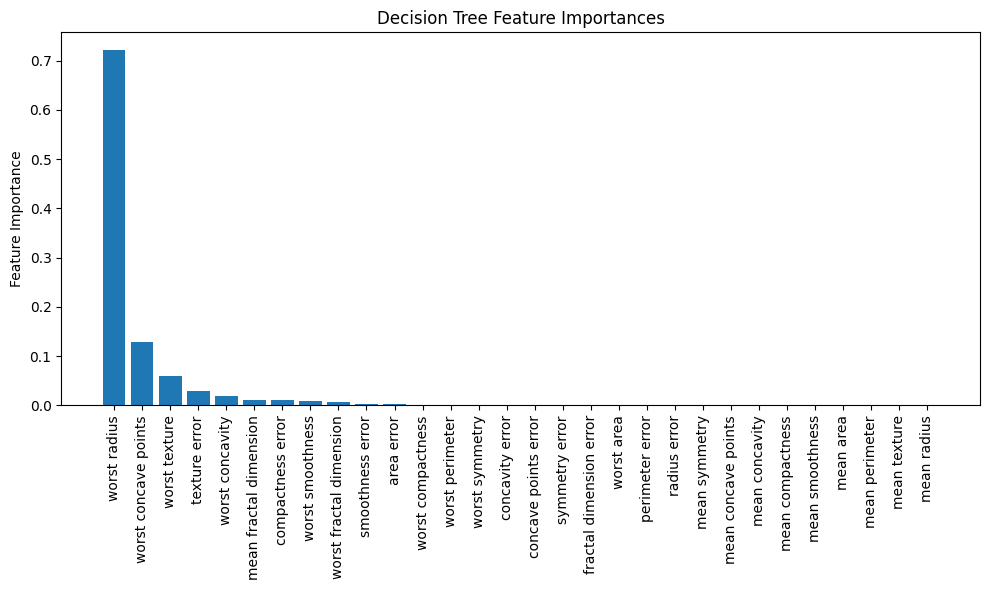

In [26]:
import matplotlib.pyplot as plt
importances = tree_clf.feature_importances_
indices = np.argsort(importances)[::-1]
plt.figure(figsize=(10, 6))
plt.bar(range(len(importances)), importances[indices])
plt.xticks(range(len(importances)), cancer.feature_names[indices], rotation=90)
plt.ylabel("Feature Importance")
plt.title("Decision Tree Feature Importances")
plt.tight_layout()
plt.show()

# Part 2: Regression

In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [28]:
# Fetching the housing data
from sklearn.datasets import fetch_california_housing
housing_data = fetch_california_housing()

In [ ]:
# Here you can print out the description of the dataset
# print(housing_data["DESCR"])

In this part of the assignment we are working with new data type - a pandas DataFrame. You can read more here: https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.html

In [29]:
# Converting the dataset into a pandas DataFrame
california = pd.DataFrame(housing_data.data)
# Preserving the feature names as the column names
california.columns = housing_data.feature_names

In [30]:
#Adding the target column Price to the DataFrame
california['PRICE'] = housing_data.target

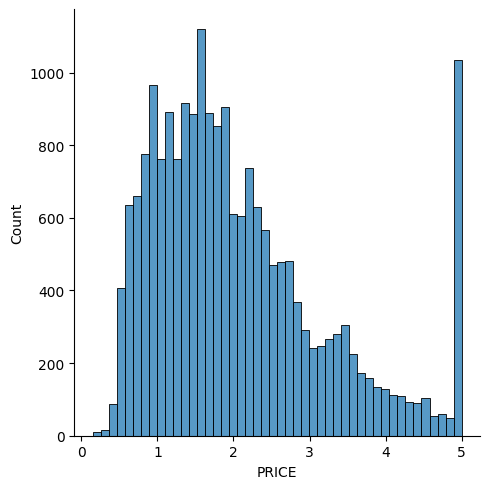

In [31]:
# Distribution of the values in the target PRICE column
sns.displot(california["PRICE"])
plt.show()

### Task 7: Exploring the housing dataset (2p)

#### Try using DataFrame methods 'head' and 'tail'. Print the first ten rows of the housing dataset (california)

In [32]:
california.head(10)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,PRICE
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
5,4.0368,52.0,4.761658,1.103627,413.0,2.139896,37.85,-122.25,2.697
6,3.6591,52.0,4.931907,0.951362,1094.0,2.128405,37.84,-122.25,2.992
7,3.1200,52.0,4.797527,1.061824,1157.0,1.788253,37.84,-122.25,2.414
8,2.0804,42.0,4.294118,1.117647,1206.0,2.026891,37.84,-122.26,2.267
9,3.6912,52.0,4.970588,0.990196,1551.0,2.172269,37.84,-122.25,2.611


#### The .info() method for the DataFrame class returns the shape of the frame and the types of the objects in it. The .describe() method gives a summary statistics for the numerical features.
#### Apply the DataFrame method 'describe' to the dataset and output the results.

In [33]:
california.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,PRICE
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


#### Apply the DataFrame method 'info' to the dataset and output the results.

In [34]:
california.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
 8   PRICE       20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


#### Create a heatmap of the correlations in the dataset using seaborn (sns.heatmap). To do that you need to create a correlation matrix first.

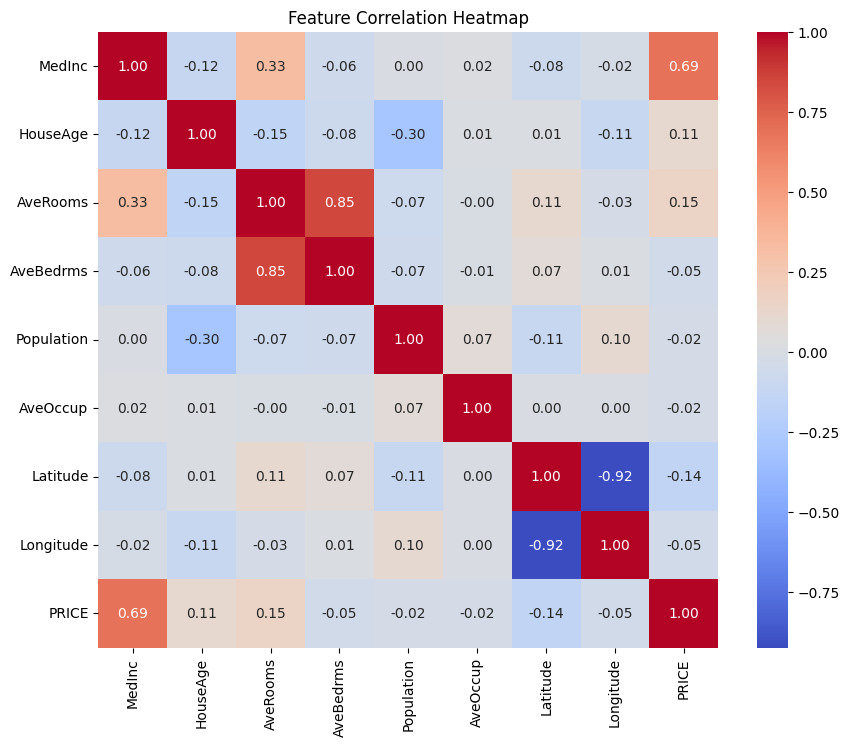

In [35]:
corr_matrix = california.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.show()

## Linear Regression

### Task 8: Linear regression algorithms

In [36]:
from sklearn.linear_model import LinearRegression
X = california.drop('PRICE', axis = 1) 
y = california['PRICE'] #Target variable

#### Split the dataset into train (75%) and test (25%) sets

In [37]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

#### Train a linear regression model (LinearRegression from sklearn), and print out the coefficients

In [38]:
linreg = LinearRegression()
linreg.fit(X_train, y_train)
print("Coefficients:")
for feature, coef in zip(X.columns, linreg.coef_):
    print(f"{feature}: {coef:.4f}")

Coefficients:
MedInc: 0.4476
HouseAge: 0.0096
AveRooms: -0.1248
AveBedrms: 0.7945
Population: -0.0000
AveOccup: -0.0034
Latitude: -0.4186
Longitude: -0.4334


#### Make the price prediction, save them in the pred variable, and run the cells below to plot them and evaluate using different metrics

In [39]:
pred = linreg.predict(X_test)

Text(0, 0.5, 'Predicted prices')

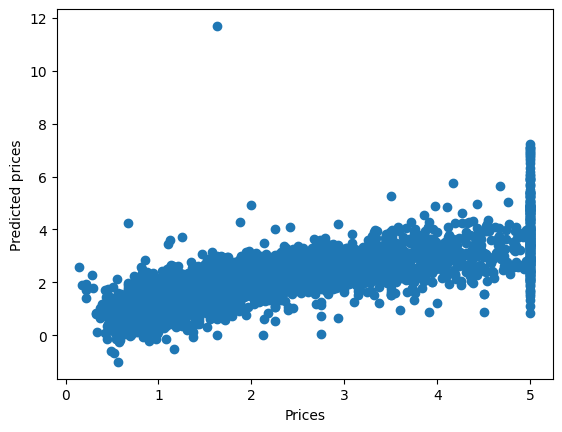

In [40]:
plt.scatter(y_test,pred)
plt.xlabel("Prices")
plt.ylabel("Predicted prices")

In [41]:
from sklearn import metrics
print('MAE:', metrics.mean_absolute_error(y_test, pred))
print('MSE:', metrics.mean_squared_error(y_test, pred))
print('RMSE:', np.sqrt(metrics.mean_squared_error(y_test, pred)))

MAE: 0.5296964012919458
MSE: 0.5411287478470685
RMSE: 0.7356145375446766


#### Implement Ridge or Lasso regression (set alpha to 1.0)

In [42]:
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso

# step-1: Create a ridge or lasso regression model
ridge_model = Ridge(alpha=1.0)

# step-2: Fit to the training data (i.e., X_train and y_train)
ridge_model.fit(X_train, y_train)

# step-3: Apply the model to predict on the testing data (i.e., X_test)
pred = ridge_model.predict(X_test)

# step-4: Print prediction performance RMSE
print("Model: Ridge(alpha=1.0)")

# Calculate performance metrics (MAE, MSE, RMSE)
print('MAE:', metrics.mean_absolute_error(y_test,pred))
print('MSE:', metrics.mean_squared_error(y_test, pred))
print('RMSE:', np.sqrt(metrics.mean_squared_error(y_test, pred)))

Model: Ridge(alpha=1.0)
MAE: 0.5297012529482946
MSE: 0.5410468729073389
RMSE: 0.7355588847314257


### Question 3: What is the relationship between Ridge and Lasso regression and linear regression? How do Ridge and Lasso regression differ from each other? (0p, mendatory)

Ridge and Lasso are both regularized versions of linear regression. Linear regression minimizes the residual error only, while Ridge/Lasso add a penalty term to reduce overfitting. Ridge uses an L2 penalty, which shrinks coefficients but usually keeps all features. Lasso uses an L1 penalty, which can drive some coefficients exactly to zero, so it can also work as feature selection.

## Decision Tree

### Task 9: Using a Decision Tree as a regressor model (2p)

#### Fit a decision tree model to the training data (use the split from Task 7)

In [43]:
from sklearn.tree import DecisionTreeRegressor
regressor = DecisionTreeRegressor(random_state=42)
regressor.fit(X_train, y_train)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_l

#### Visulaize the decision tree using Text Representation (for this initialise and train a new tree and set max_depth = 3, to keep it small). Export your tree as text and save it as text_representation. 
#### More on text export here: https://scikit-learn.org/stable/modules/generated/sklearn.tree.export_text.html, and here is an additional blog post: https://mljar.com/blog/extract-rules-decision-tree/

|--- MedInc <= 5.03
|   |--- MedInc <= 3.07
|   |   |--- AveRooms <= 4.20
|   |   |   |--- value: [1.66]
|   |   |--- AveRooms >  4.20
|   |   |   |--- value: [1.18]
|   |--- MedInc >  3.07
|   |   |--- AveOccup <= 2.35
|   |   |   |--- value: [2.81]
|   |   |--- AveOccup >  2.35
|   |   |   |--- value: [1.88]
|--- MedInc >  5.03
|   |--- MedInc <= 7.02
|   |   |--- AveOccup <= 2.75
|   |   |   |--- value: [3.41]
|   |   |--- AveOccup >  2.75
|   |   |   |--- value: [2.60]
|   |--- MedInc >  7.02
|   |   |--- MedInc <= 8.42
|   |   |   |--- value: [3.97]
|   |   |--- MedInc >  8.42
|   |   |   |--- value: [4.72]



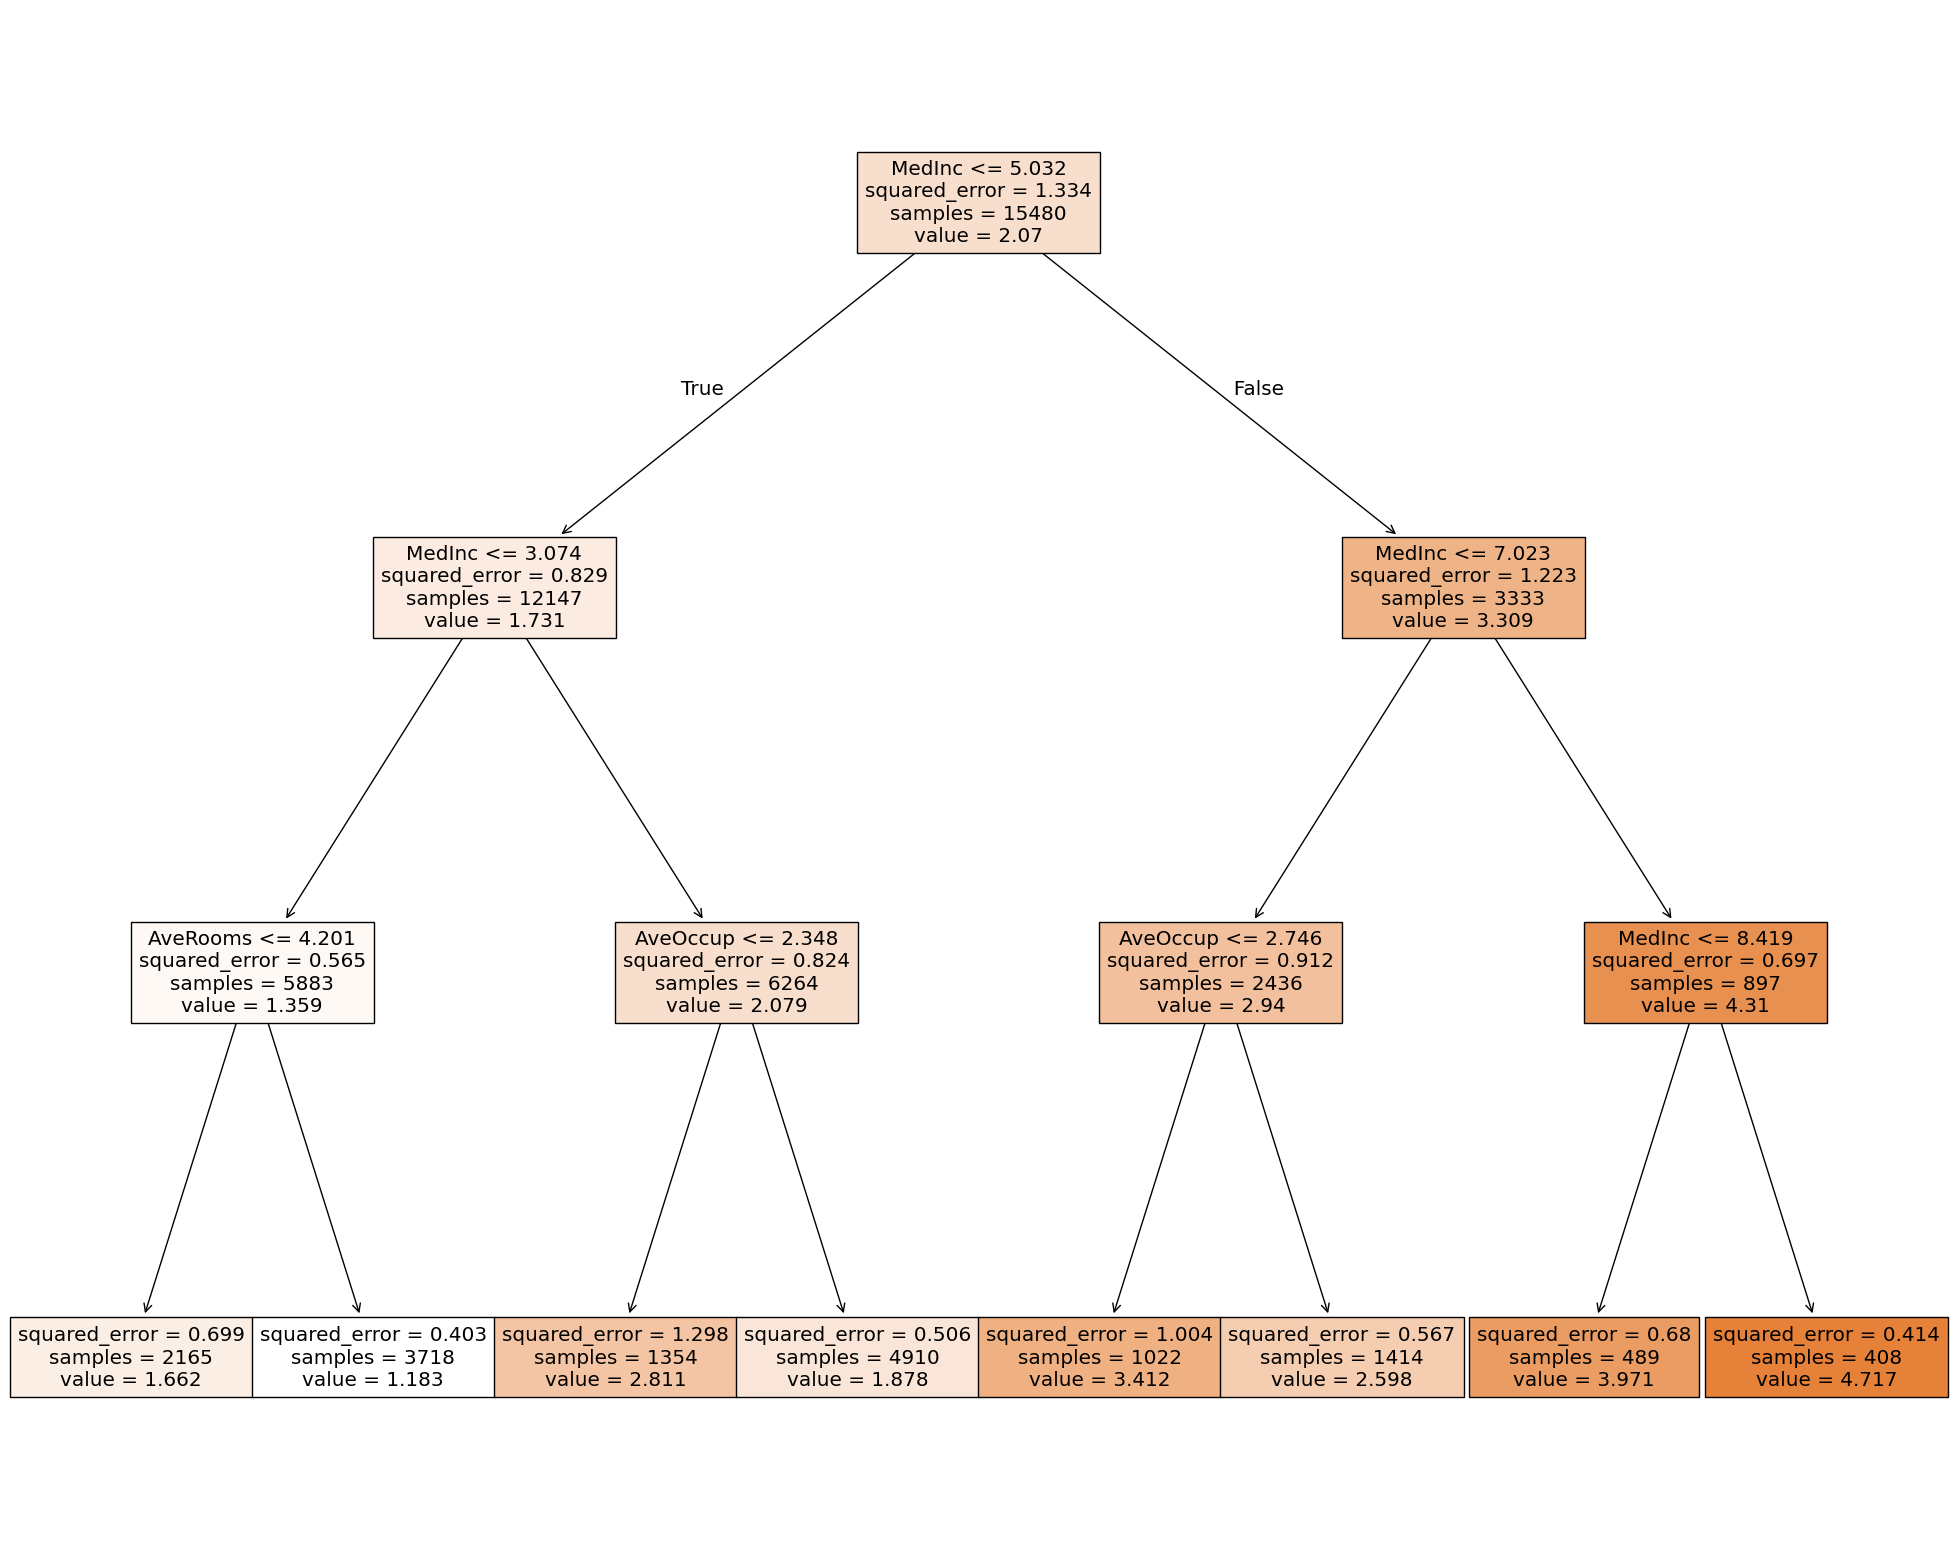

In [44]:
from sklearn import tree
regressor = DecisionTreeRegressor(random_state=42, max_depth=3)
regressor.fit(X_train, y_train)
text_representation = tree.export_text(regressor, feature_names=list(X_train.columns))
print(text_representation)
fig = plt.figure(figsize=(25,20))
_ = tree.plot_tree(regressor, feature_names=X_train.columns, filled=True)

#### Make predictions for the test set and calculate Mean Square and Mean Absolute Error

In [45]:
pred = regressor.predict(X_test)
print('MSE:', metrics.mean_squared_error(y_test, pred))
print('MAE:', metrics.mean_absolute_error(y_test, pred))

MSE: 0.640829077514131
MAE: 0.6001895862815657


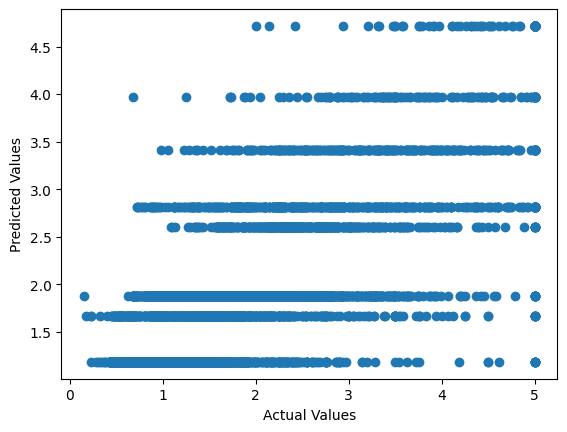

In [46]:
#### Plot the predicted values against the actual values
plt.scatter(y_test, pred)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.show()

#### Does your model fit the data well? Write a brief explanation of your results

The model captures the overall trend, but it does not fit perfectly. In the scatter plot, many points are not on the ideal diagonal line, which means prediction errors are still present. The MSE and MAE values show the model is usable, but there is clear room for improvement through hyperparameter tuning.

### Task 10: Improving the Decision Tree Regressor (4p)

#### Complete the script code below to iterate over different the maximum depth values and calculate and plot MSE and MAE for each of them

Best max_depth by MSE: 9


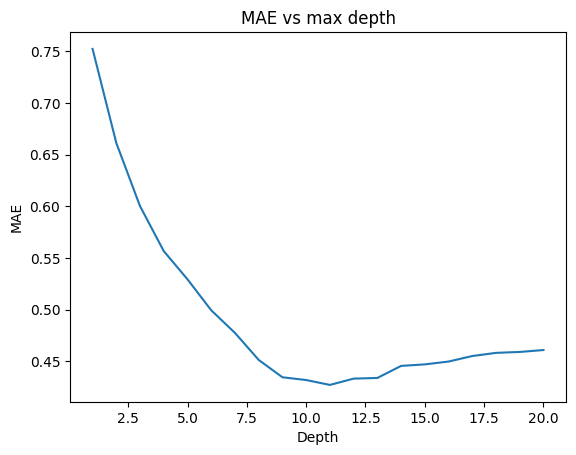

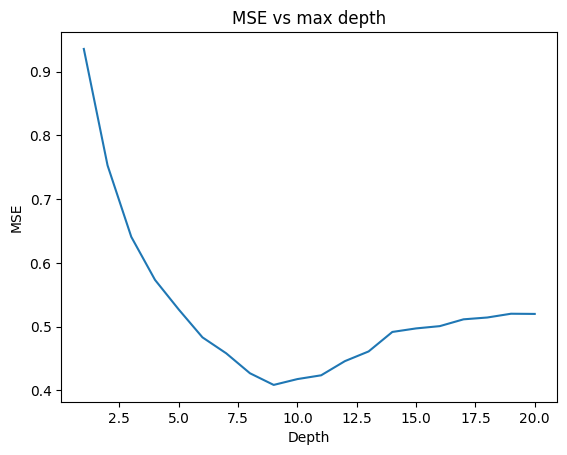

In [47]:
mae = []
mse = []
depth = [i for i in range(1, 21)]

for d in depth:
    regressor = DecisionTreeRegressor(random_state=42, max_depth=d)
    regressor.fit(X_train, y_train)
    predictions = regressor.predict(X_test)
    mse.append(metrics.mean_squared_error(y_test, predictions))
    mae.append(metrics.mean_absolute_error(y_test, predictions))

best_depth = depth[int(np.argmin(mse))]
print(f"Best max_depth by MSE: {best_depth}")

plt.plot(depth, mae)
plt.xlabel("Depth")
plt.ylabel("MAE")
plt.title("MAE vs max depth")
plt.show()

plt.plot(depth, mse)
plt.xlabel("Depth")
plt.ylabel("MSE")
plt.title("MSE vs max depth")
plt.show()

#### Based on the plot, what is the best value for max_depth and why?

From my plot, the best value was `max_depth = 9` because it gave the lowest test MSE (and near-minimum MAE). Smaller depths underfit and miss important patterns, while larger depths started to increase error again, which indicates overfitting.

#### How can the model be further improved? Which other parameters can be optimized?
#### Repeat the previous step yourself, but this time choose a different parameter and range to tune. Do not forget to use the best max_depth value that you found earlier.
#### See: https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeRegressor.html#sklearn.tree.DecisionTreeRegressor

Best min_samples_leaf by MSE: 20


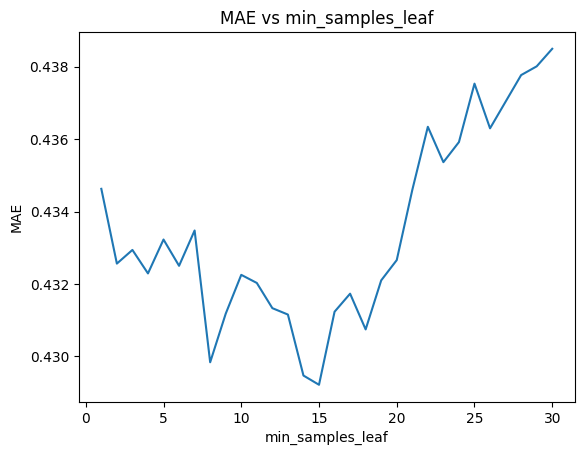

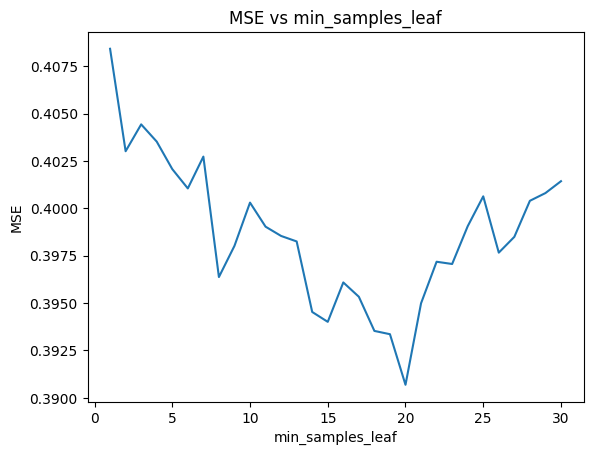

In [48]:
leaf_values = range(1, 31)
leaf_mse = []
leaf_mae = []

for leaf in leaf_values:
    model = DecisionTreeRegressor(
        random_state=42,
        max_depth=best_depth,
        min_samples_leaf=leaf
    )
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    leaf_mse.append(metrics.mean_squared_error(y_test, preds))
    leaf_mae.append(metrics.mean_absolute_error(y_test, preds))

best_leaf = list(leaf_values)[int(np.argmin(leaf_mse))]
print(f"Best min_samples_leaf by MSE: {best_leaf}")

regressor = DecisionTreeRegressor(
    random_state=42,
    max_depth=best_depth,
    min_samples_leaf=best_leaf
)
regressor.fit(X_train, y_train)

plt.plot(list(leaf_values), leaf_mae)
plt.xlabel("min_samples_leaf")
plt.ylabel("MAE")
plt.title("MAE vs min_samples_leaf")
plt.show()

plt.plot(list(leaf_values), leaf_mse)
plt.xlabel("min_samples_leaf")
plt.ylabel("MSE")
plt.title("MSE vs min_samples_leaf")
plt.show()

#### Which combination of parameters worked best and why?

The best combination in my tuning was `max_depth = 9` and `min_samples_leaf = 20` based on the lowest test MSE. This worked best because `max_depth` controls tree complexity and `min_samples_leaf` prevents leaves from becoming too small, which improves generalization and reduces overfitting.

#### Visualize feture importances for your best decision tree model
#### Optional: If you would like to visualize the features in the each node you can also use dtreeviz package.

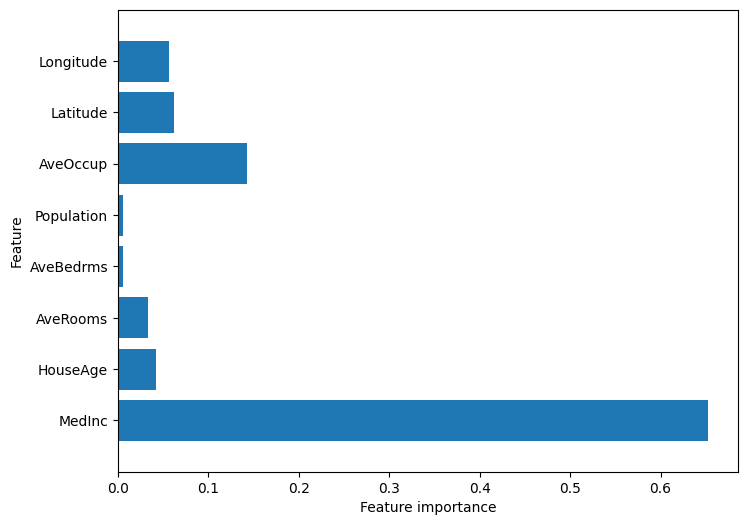

In [49]:
#### Visualize Features Importance
housing_features = [x for i,x in enumerate(california.columns) if i!=8]
def plot_feature_importances_housing(model):
    plt.figure(figsize=(8,6))
    n_features = 8
    plt.barh(range(n_features), model.feature_importances_, align='center')
    plt.yticks(np.arange(n_features), housing_features)
    plt.xlabel("Feature importance")
    plt.ylabel("Feature")
    plt.ylim(-1, n_features)
plot_feature_importances_housing(regressor)
plt.savefig('feature_importance')